In [1]:
import warnings
warnings.filterwarnings('ignore')

# from IPython.core.display import display, HTML
# display(HTML('<style>.container {width: 100% !important; }</style>'))

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
import seaborn as sns

In [3]:
path = "/project/Wellcome_Discovery/datashare/lturiano/data/"

In [4]:
dict_genes = {'T cell': ['ENSG00000156482',
  'ENSG00000134419',
  'ENSG00000171858',
  'ENSG00000112306',
  'ENSG00000149273'],
 'dendritic cell': ['ENSG00000019582',
  'ENSG00000204287',
  'ENSG00000223865',
  'ENSG00000231389',
  'ENSG00000138326'],
 'duct cell': ['ENSG00000143153',
  'ENSG00000119888',
  'ENSG00000272398',
  'ENSG00000101443',
  'ENSG00000240972'],
 'endothelial cell': ['ENSG00000172889',
  'ENSG00000065054',
  'ENSG00000127920',
  'ENSG00000261371',
  'ENSG00000165949'],
 'epithelial cell': ['ENSG00000272398',
  'ENSG00000143153',
  'ENSG00000119888',
  'ENSG00000167642',
  'ENSG00000111057'],
 'fibroblast': ['ENSG00000011465',
  'ENSG00000111341',
  'ENSG00000139329',
  'ENSG00000159403',
  'ENSG00000132386'],
 'lymphocyte': ['ENSG00000166710',
  'ENSG00000105374',
  'ENSG00000234745',
  'ENSG00000206503',
  'ENSG00000110848'],
 'macrophage': ['ENSG00000019582',
  'ENSG00000204287',
  'ENSG00000196126',
  'ENSG00000011600',
  'ENSG00000231389'],
 'mural cell': ['ENSG00000101335',
  'ENSG00000122786',
  'ENSG00000163453',
  'ENSG00000143248',
  'ENSG00000185633'],
 'myeloid cell': ['ENSG00000087086',
  'ENSG00000158869',
  'ENSG00000204472',
  'ENSG00000011600',
  'ENSG00000163220'],
 'myocyte': ['ENSG00000118194',
  'ENSG00000129991',
  'ENSG00000175084',
  'ENSG00000198125',
  'ENSG00000173991'],
 'neural cell': ['ENSG00000078328',
  'ENSG00000198763',
  'ENSG00000198840',
  'ENSG00000228253',
  'ENSG00000212907']}

# GEX vs scRNA

In [ ]:
# ### To comment after running

# np.random.seed(42)

# if norm:
#     gene_exp = sc.read_h5ad(path+"GEX_filt_norm.h5ad")
#     scrna    = sc.read_h5ad(path+"RNA_filt_norm.h5ad")
# else:
#     gene_exp = sc.read_h5ad(path+"GEX_filt_log.h5ad")
#     scrna    = sc.read_h5ad(path+"RNA_filt_log.h5ad")

# # Count cell types
# cells1 = gene_exp.obs.cell_type.value_counts().to_dict()
# cells2 = scrna.obs.cell_type.value_counts().to_dict()

# # Create a dictionary with minimum values
# cell_types = {
#     key: min(cells1.get(key, 0), cells2.get(key, 0)) 
#     for key in set(cells1.keys()) | set(cells2.keys())
# }

# indeces = {}
# for ct in cell_types:
#     cells = scrna[scrna.obs["cell_type"]== ct].obs.index.to_numpy()
#     cells = np.random.choice(cells, cell_types[ct], replace=False)
#     indeces[ct] = cells
# flat_cells = [item for sublist in indeces.values() for item in sublist]
# scrna_sub = scrna[scrna.obs.index.isin(flat_cells)]
# scrna_sub = scrna_sub[scrna_sub.obs.sort_values("cell_type").index.tolist(), :]

# indeces = {}
# for ct in cell_types:
#     cells = gene_exp[gene_exp.obs["cell_type"]== ct].obs.index.to_numpy()
#     cells = np.random.choice(cells, cell_types[ct], replace=False)
#     indeces[ct] = cells
# flat_cells = [item for sublist in indeces.values() for item in sublist]
# gene_exp_sub = gene_exp[gene_exp.obs.index.isin(flat_cells)]
# gene_exp_sub = gene_exp_sub[gene_exp_sub.obs.sort_values("cell_type").index.tolist(), :]


# inter_genes = set(scrna_sub.var_names).intersection(set(gene_exp_sub.var_names))
# diff_genes = set(scrna_sub.var_names).difference(set(gene_exp_sub.var_names))
# ordered_genes = list(inter_genes)+list(diff_genes)

# scrna_sub = scrna_sub[:, ordered_genes].copy()
# gene_exp_sub = gene_exp_sub[:, list(inter_genes)].copy()

# if norm:
#     scrna_sub.write_h5ad(path+"RNA_filt_norm_subset.h5ad", compression="gzip")
#     gene_exp_sub.write(path+"GEX_filt_norm_subset.h5ad", compression="gzip")
# else:
#     scrna_sub.write_h5ad(path+"RNA_filt_log_subset.h5ad", compression="gzip")
#     gene_exp_sub.write(path+"GEX_filt_log_subset.h5ad", compression="gzip")

# del gene_exp
# del scrna_sub

In [5]:
scrna_sub = sc.read_h5ad(path+"rna_filt_aligned.h5ad")
gene_exp_sub = sc.read_h5ad(path+"gex_filt_aligned.h5ad")

In [6]:
scrna_sub.obs['cell_type']    = scrna_sub.obs['cell_type'].astype('category')
gene_exp_sub.obs['cell_type'] = gene_exp_sub.obs['cell_type'].astype('category')

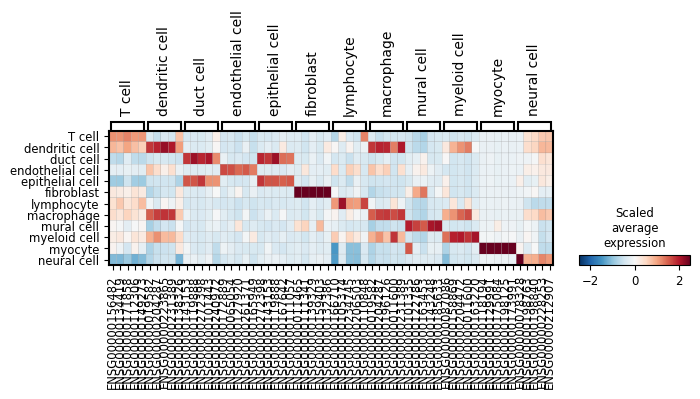

In [8]:
scrna_sub_matrix = scrna_sub.copy()
scrna_sub_matrix.var.set_index(scrna_sub_matrix.var_names, inplace=True)
scrna_sub_matrix.raw = scrna_sub_matrix.copy()
sc.pp.scale(scrna_sub_matrix, max_value=10)

sc.pl.matrixplot(
    scrna_sub_matrix,
    dict_genes,
    "cell_type",
    dendrogram=False,
    colorbar_title="Scaled\naverage\nexpression",
    cmap="RdBu_r",
    use_raw=False,
    vmin=-2.5,
    vmax=2.5,
    figsize=(7.5,1.75),
)

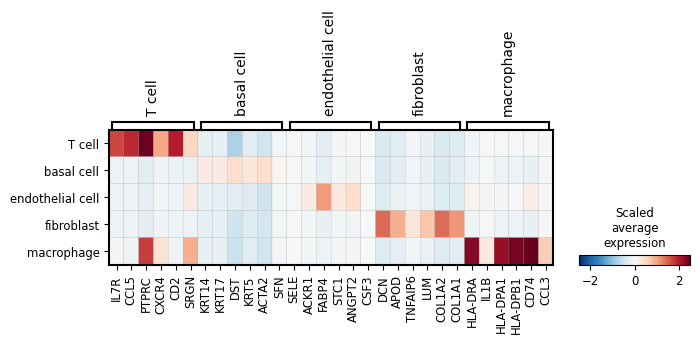

In [114]:
# gene_exp_sub_matrix = gene_exp_sub.copy()
# gene_exp_sub_matrix.var.set_index(gene_exp_sub_matrix.var['feature_name'], inplace=True)
# gene_exp_sub_matrix.raw = gene_exp_sub_matrix.copy()
# sc.pp.scale(gene_exp_sub_matrix, max_value=10)

sc.pl.matrixplot(
    gene_exp_sub_matrix,
    dict_genes,
    "cell_type",
    dendrogram=False,
    colorbar_title="Scaled\naverage\nexpression",
    cmap="RdBu_r",
    use_raw=False,
    vmin=-2.5,
    vmax=2.5,
    figsize=(7.5,1.75),
)

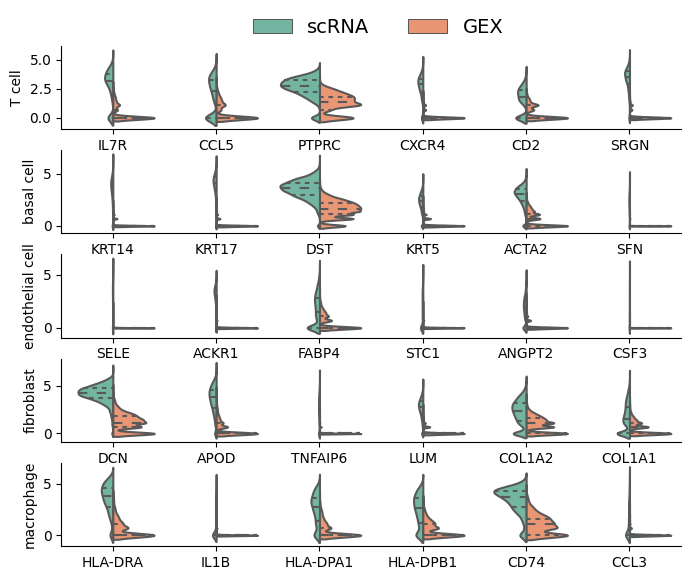

In [129]:
df_rna_all = pd.DataFrame(data=scrna_sub.X, 
                          columns=scrna_sub.var.feature_name.tolist(), 
                          index=scrna_sub.obs.index.tolist())
df_rna_all['cell_type'] = scrna_sub.obs['cell_type'].tolist()
df_rna_all['type'] = 'scRNA'

df_gex_all = pd.DataFrame(data=gene_exp_sub.X, 
                          columns=gene_exp_sub.var.feature_name.tolist(), 
                          index=gene_exp_sub.obs.index.tolist())
df_gex_all['cell_type'] = gene_exp_sub.obs['cell_type'].tolist()
df_gex_all['type'] = 'GEX'

f, ax = plt.subplots(len(dict_genes.keys()), 1, figsize=(8,6.5), sharex=False)
sns.despine()
for idx, ct in enumerate(dict_genes.keys()):
    
    df_rna = df_rna_all[df_rna_all['cell_type']==ct][list(dict_genes[ct])+['type']]
    df_gex = df_gex_all[df_gex_all['cell_type']==ct][list(dict_genes[ct])+['type']]
    df = pd.concat([df_rna, df_gex])

    # Melt the DataFrame to long format
    df_long = pd.melt(df, id_vars='type', value_vars=dict_genes[ct], 
                      var_name='variable', value_name=ct)

    sns.violinplot(x='variable', 
                   y=ct,
                   hue='type',
                   data=df_long,
                   split=True, 
                   inner='quartile',
                   palette='Set2',
                   ax=ax[idx])
    ax[idx].get_legend().remove()
    ax[idx].set_xlabel("")

# ax[len(dict_genes.keys())-1].set_xlabel("Gene", fontsize=12)

lines_labels = [ax.get_legend_handles_labels() for ax in f.axes[:1]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
f.legend(lines, labels, frameon=False, bbox_to_anchor=(.70, .95), ncol=2, fontsize=14)
# plt.suptitle("scRNA vs GEX")
plt.subplots_adjust(wspace=0, hspace=0.25)
plt.show()
f.savefig("figures/Figure3.pdf", bbox_inches ="tight") 

# Evaluation

In [180]:
# Create the initial data dictionary
data = {
    'RNA_f1': [0.9996208510708225],
    'GEX_f1': [0.5543369876804768],
    'VAE_f1': [0.346012128172859],
    'GAN_f1': [0.7938288056782505],
    'VAE_UNET_f1': [0.9717070571076807]
}

# Create initial DataFrame
df = pd.DataFrame(data)
df

,RNA_f1,GEX_f1,VAE_f1,GAN_f1,VAE_UNET_f1
0,0.999621,0.554337,0.346012,0.793829,0.971707


In [186]:
# Create the initial data dictionary
data = {
    'RNA_f1': [0.9996208510708225],
    'GEX_f1': [0.5543369876804768],
    'VAE_f1': [0.346012128172859],
    'GAN_f1': [0.7938288056782505],
    'VAE_UNET_f1': [0.9717070571076807]
}

# Create initial DataFrame
df = pd.DataFrame(data)

# Melt the DataFrame to get it into long format
df_long = df.melt(var_name='Model', 
                  value_name='F1_Score')

# Clean up the Metric names by removing '_f1'
df_long['Model'] = df_long['Model'].str.replace('_f1', '')

display(df_long.round(4))

,Model,F1_Score
0,RNA,0.9996
1,GEX,0.5543
2,VAE,0.3460
3,GAN,0.7938
4,VAE_UNET,0.9717


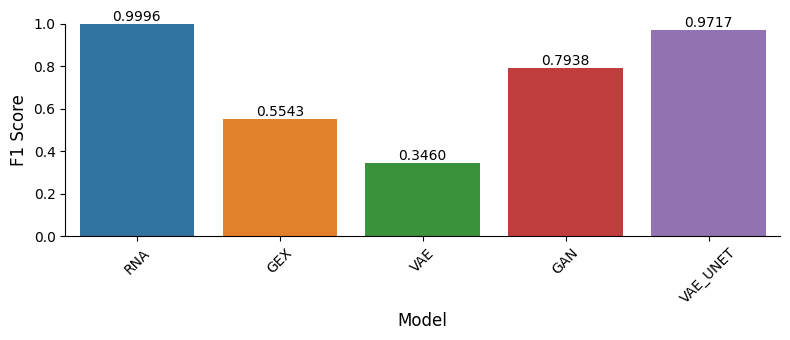

In [192]:
# Create the bar plot
plt.figure(figsize=(8, 3.5))
sns.barplot(x='Model', y='F1_Score', data=df_long)

# Remove top and right axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Customize the plot
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1)  # Set y-axis from 0 to 1

# Add value labels on top of each bar
for i, v in enumerate(df_long['F1_Score']):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')

# Rotate x-axis labels if needed
plt.xticks(rotation=45)

# Adjust layout and show the plot
plt.tight_layout()
plt.savefig('figures/f1_scores_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Fake* vs GEX/scRNA

In [119]:
fake = sc.read_h5ad(path+"Fake_RNA_VAE_UNET_log.h5ad")

In [120]:
fake.obs['cell_type'] = fake.obs['cell_type'].astype('category')

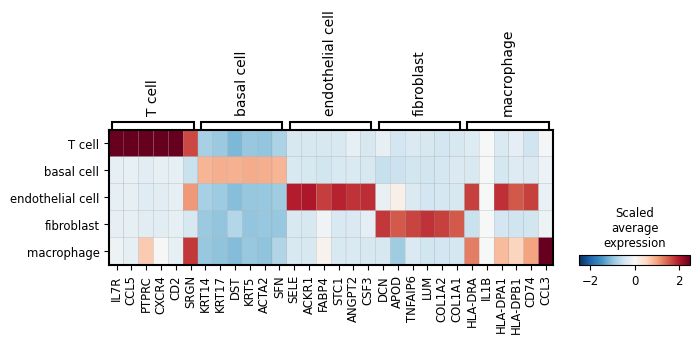

In [170]:
fake_matrix = fake.copy()
fake_matrix.var.set_index(fake_matrix.var['feature_name'], inplace=True)
fake_matrix.raw = fake_matrix.copy()
sc.pp.scale(fake_matrix, max_value=10)

sc.pl.matrixplot(
    fake_matrix,
    dict_genes,
    "cell_type",
    dendrogram=False,
    colorbar_title="Scaled\naverage\nexpression",
    cmap="RdBu_r",
    use_raw=False,
    vmin=-2.5,
    vmax=2.5,
    figsize=(7.5,1.75),
    save='figures/Figure4.pdf'
)

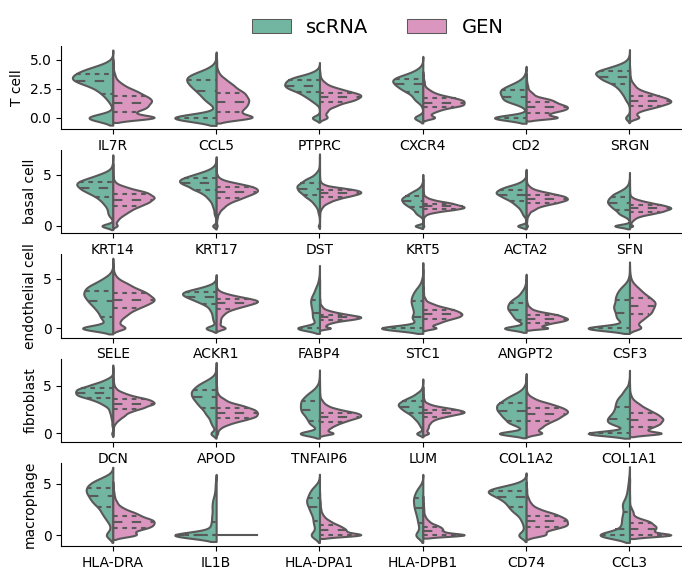

In [172]:
df_rna_all = pd.DataFrame(data=scrna_sub.X, 
                          columns=scrna_sub.var.feature_name.tolist(), 
                          index=scrna_sub.obs.index.tolist())
df_rna_all['cell_type'] = scrna_sub.obs['cell_type'].tolist()
df_rna_all['type'] = 'scRNA'

df_fake_all = pd.DataFrame(data=fake.X, 
                           columns=fake.var.feature_name.tolist(), 
                           index=fake.obs.index.tolist())
df_fake_all['cell_type'] = fake.obs['cell_type'].tolist()
df_fake_all['type'] = 'GEN'

f, ax = plt.subplots(len(dict_genes.keys()), 1, figsize=(8,6.5), sharex=False)
sns.despine()
for idx, ct in enumerate(dict_genes.keys()):
    
    df_rna = df_rna_all[df_rna_all['cell_type']==ct][list(dict_genes[ct])+['type']]
    df_fake = df_fake_all[df_fake_all['cell_type']==ct][list(dict_genes[ct])+['type']]
    df = pd.concat([df_rna, df_fake])

    # Melt the DataFrame to long format
    df_long = pd.melt(df, id_vars='type', value_vars=dict_genes[ct], 
                      var_name='variable', value_name=ct)

    sns.violinplot(x='variable', 
                   y=ct,
                   hue='type',
                   data=df_long,
                   split=True, 
                   inner='quartile',
                   palette=sns.color_palette("Set2")[:1]+sns.color_palette("Set2")[3:],
                   ax=ax[idx])
    ax[idx].get_legend().remove()
    ax[idx].set_xlabel("")
    
lines_labels = [ax.get_legend_handles_labels() for ax in f.axes[:1]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
f.legend(lines, labels, frameon=False, bbox_to_anchor=(.70, .95), ncol=2, fontsize=14)
# plt.suptitle("scRNA vs scRNA GAN log")
plt.subplots_adjust(wspace=0, hspace=0.25)
plt.show()
f.savefig("figures/Figure5.pdf", bbox_inches ="tight") 

# Analyse Fake PI VAE UNET data

In [4]:
fake = sc.read_h5ad(path+"fake_RNA_PermInv_VAE_UNET.h5ad")

In [5]:
fake.X.min(), fake.X.max(), fake.X.mean()

(np.float32(0.0), np.float32(8.988678), np.float32(0.03529376))

In [6]:
# check if X has nan
np.isnan(fake.X).any()

np.False_

In [8]:
np.asarray(fake.obs['cell_type'].values)

array(['T cell', 'T cell', 'T cell', ..., 'neural cell', 'neural cell',
       'neural cell'], dtype=object)

In [ ]:
# Build: cell_type -> list of indices in adata2
        tgt_ct = np.asarray(adata2.obs[self.cell_type_key].values)
        self.ct_to_tgt_indices = {}
        for ct in np.unique(tgt_ct):
            self.ct_to_tgt_indices[ct] = np.where(tgt_ct == ct)[0]